Loaded 103 CSV files
Unique questions: 660
Correct: 373
Overall accuracy: 29.51%


/tmp/ipykernel_2588595/3142535254.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  acc_by_bin = df.groupby("token_bin")["is_correct"].mean() * 100


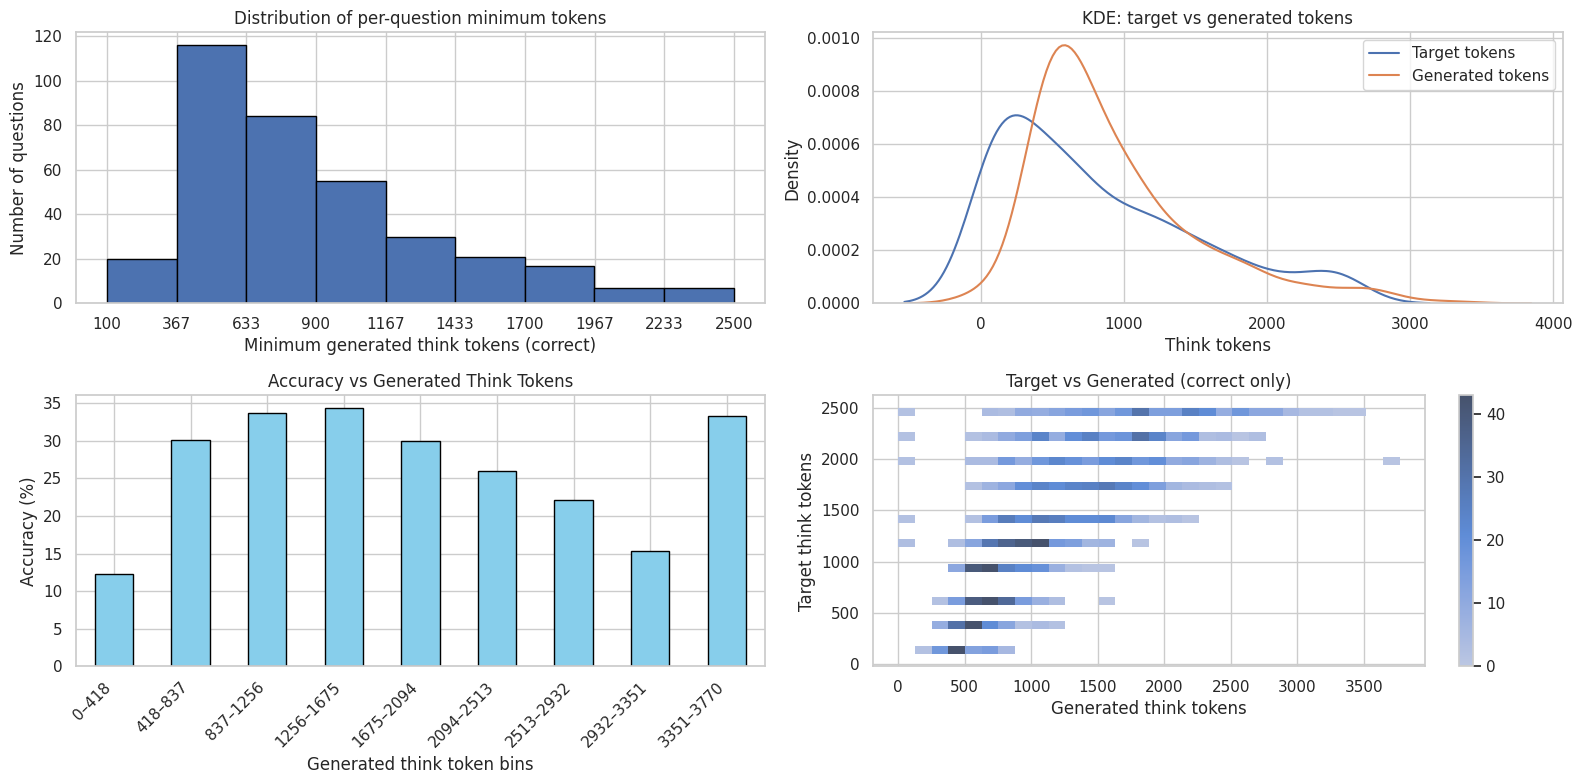

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set(style="whitegrid")
import matplotlib.pyplot as plt
data_dir = Path("..") / "generated_aime_dataset"
csv_files = [f for f in data_dir.iterdir() if f.suffix == ".csv"]
df = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)

print(f"Loaded {len(csv_files)} CSV files")
print(f"Unique questions: {df['question_id'].nunique()}")
num = df.loc[df["is_correct"], "question_id"].nunique()
print(f"Correct: {num}")
print(f"Overall accuracy: {df['is_correct'].mean() * 100:.2f}%")

tokens = np.round(np.linspace(100, 2500, num=10, endpoint=True)).astype(int)
correct = df[df["is_correct"]]
incorrect = df[~df["is_correct"]]

min_tokens = correct.groupby("question_id")["generated_think_tokens"].min().sort_values()
min_tokens_target = correct.groupby("question_id")["target_think_tokens"].min()

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.ravel()

axes[0].hist(
    min_tokens,
    bins=np.append(tokens - 0.5, tokens[-1] + 0.5),
    edgecolor="black",
)
axes[0].set_xticks(tokens)
axes[0].set_xlabel("Minimum generated think tokens (correct)")
axes[0].set_ylabel("Number of questions")
axes[0].set_title("Distribution of per-question minimum tokens")

sns.kdeplot(min_tokens_target, ax=axes[1], label="Target tokens")
sns.kdeplot(min_tokens, ax=axes[1], label="Generated tokens")
axes[1].set_xlabel("Think tokens")
axes[1].set_ylabel("Density")
axes[1].set_title("KDE: target vs generated tokens")
axes[1].legend()

bin_edges = np.linspace(0, df["generated_think_tokens"].max(), 10)
df["token_bin"] = pd.cut(df["generated_think_tokens"], bins=bin_edges, include_lowest=True)
acc_by_bin = df.groupby("token_bin")["is_correct"].mean() * 100

acc_by_bin.plot(kind="bar", ax=axes[2], edgecolor="black", color="skyblue")
axes[2].set_ylabel("Accuracy (%)")
axes[2].set_xlabel("Generated think token bins")
axes[2].set_title("Accuracy vs Generated Think Tokens")
axes[2].set_xticklabels(
    [f"{int(b.left)}–{int(b.right)}" for b in acc_by_bin.index],
    rotation=45,
    ha="right"
)

sns.histplot(
    correct,
    x="generated_think_tokens",
    y="target_think_tokens",
    bins=30,
    pmax=0.9,
    cbar=True,
    ax=axes[3],
)
axes[3].set_xlabel("Generated think tokens")
axes[3].set_ylabel("Target think tokens")
axes[3].set_title("Target vs Generated (correct only)")

plt.tight_layout()
plt.show()


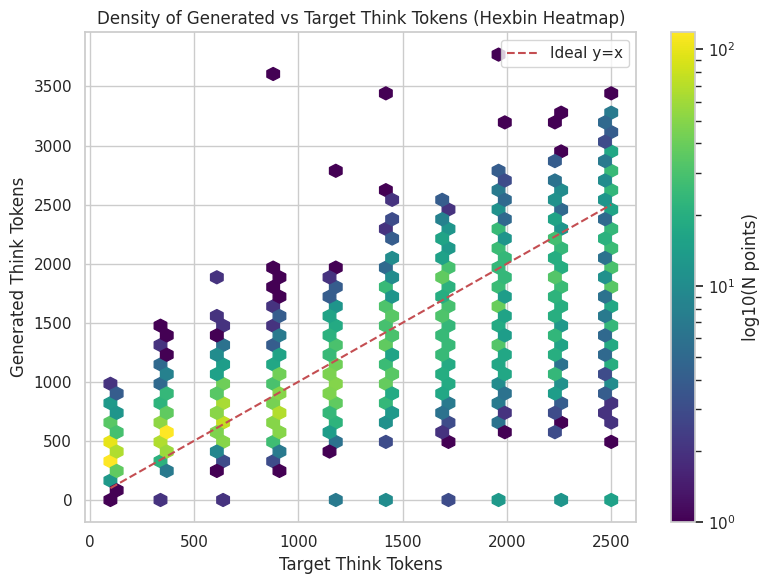

In [6]:
plt.figure(figsize=(8,6))
hb = plt.hexbin(
    df["target_think_tokens"],
    df["generated_think_tokens"],
    gridsize=40,           # number of hexes along x-axis (adjust for resolution)
    cmap="viridis",
    bins="log"             # log color scale = better for uneven densities
)
plt.colorbar(hb, label="log10(N points)")
mn, mx = df["target_think_tokens"].min(), df["target_think_tokens"].max()
plt.plot([mn, mx], [mn, mx], "r--", label="Ideal y=x")
plt.xlabel("Target Think Tokens")
plt.ylabel("Generated Think Tokens")
plt.title("Density of Generated vs Target Think Tokens (Hexbin Heatmap)")
plt.legend()
plt.tight_layout()
plt.show()
